# Continuum reverberation mapping without microlensing

The relativistic disk and transfer-function APIs are independent of the
microlensing solvers.  This notebook traces one Kerr disk, constructs its
steady axial-lamppost response, drives it with a broken-power-law stochastic
signal, and integrates ordinary multi-band continuum light curves—without a
point-mass field or magnification map.

In [1]:
from pathlib import Path
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
OUTPUT_DIRECTORY = Path('continuum_reverberation_output')
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime = mc.resolve_runtime(mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="torch-compile" if use_cuda else "auto",
    dtype=torch.float32,
))

# This source-only workflow uses the same public KerrDiskModel as a
# microlensing calculation. Omitting MicrolensingSystem is all that is needed
# to use the GR and reverberation machinery independently.
lens_redshift, source_redshift = 0.0395, 1.695
distances = mc.LensingDistances.from_redshifts(lens_redshift, source_redshift)
driver_times = torch.arange(-200.0, 3651.0, device=runtime.device, dtype=runtime.dtype)
driver = mc.broken_power_law_driving_signal(
    driver_times, break_timescale_days=200.0, low_frequency_slope=1.0,
    high_frequency_slope=3.0, standard_deviation=0.10, seed=73,
    extrapolation="hold",
)
disk_model = mc.KerrDiskModel(
    black_hole_mass_solar=10.0**9.08,
    eddington_ratio=0.34,
    wavelengths_angstrom=(3671.0, 4827.0, 6223.0, 7546.0, 8691.0, 9712.0),
    band_names=("u", "g", "r", "i", "z", "y"),
    spin=0.74,
    inclination_deg=10.0,
    source_redshift=source_redshift,
    lamp_fraction=0.1,
    corona_height_above_isco_rg=20.0,
    driving_signal=driver,
    grid=mc.SourceGridConfig(
        shape=1024 if use_cuda else 256,
        enclosed_flux_fraction=0.999,
        margin=1.05,
    ),
    compile_solver=use_cuda,
    lamppost_nalpha=1024 if use_cuda else 256,
    lamppost_radial_bins=320 if use_cuda else 112,
)
source = disk_model.pixelate(distances, runtime=runtime)
geometry = source.geometry


## Steady relativistic response

The transfer function is normalized probability mass per delay bin.  Delays
are measured relative to the earliest retained lamp--disk--observer path, so
the causal response is exactly zero for negative relative delay and is pinned
to zero at the plotted origin.  The plotting helper converts mass to density
and applies display-only smoothing inside the physical response support.

Displayed causal response support: 0--135.6 days
The zero point is the earliest retained lamp--disk--observer path.


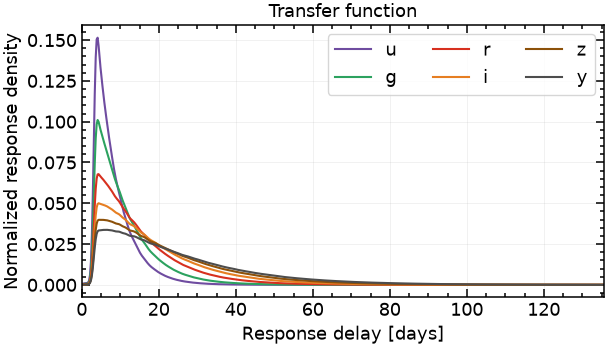

In [2]:
delay_max = float(torch.quantile(source.delay_days[source.transfer.hit], 0.9999).cpu()) + 3.0
delay_edges = torch.arange(0.0, delay_max + 0.25, 0.25, device=runtime.device, dtype=runtime.dtype)
transfer = mc.steady_transfer_function(source, delay_edges)
plot_delay, plot_density = mcp.transfer_response_density(
    transfer, smoothing_sigma_days=0.50, include_zero_boundaries=True
)
assert plot_delay[0] == 0.0 and (plot_density[0] == 0.0).all()
figure, ax = mcp.plot_transfer_function(transfer, smoothing_sigma_days=0.50)
ax.set_xlim(0.0, delay_max)
figure.tight_layout()
figure.savefig(OUTPUT_DIRECTORY / "continuum_reverberation_transfer.png", dpi=220, bbox_inches="tight", facecolor="white")
print(f"Displayed causal response support: 0--{delay_max:.1f} days")
print("The zero point is the earliest retained lamp--disk--observer path.")


## Daily driving and reprocessed continuum light curves

The driver is evaluated every day.  Each disk pixel responds at its own Kerr
and lamppost delay, after which the observer-screen intensity is integrated.
The magnitude calibration below is explicit and illustrative. No relative-
magnitude shorthand is used.

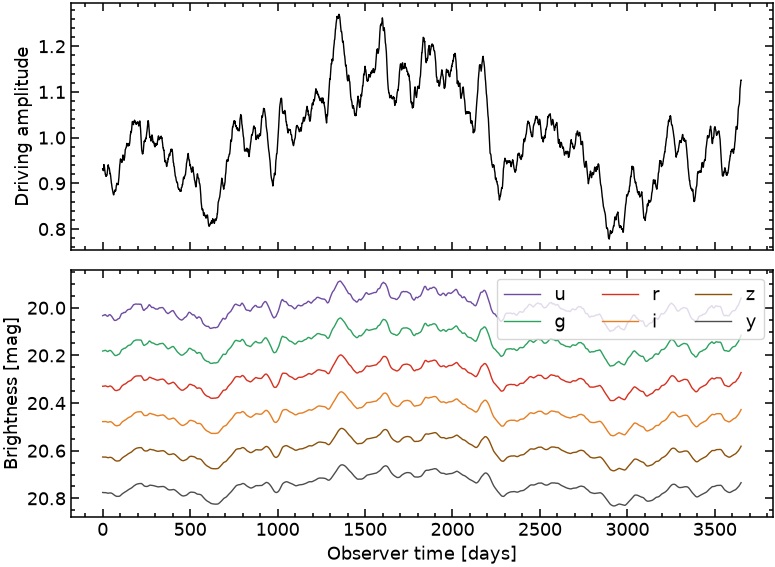

In [3]:
times = torch.arange(0.0, 3651.0, device=runtime.device)
flux_chunks = []
for start in range(0, len(times), 16):
    image = source.brightness(times[start:start + 16], device=runtime.device, dtype=runtime.dtype)
    flux_chunks.append(image.sum(dim=(1, 2)).detach().cpu())
flux = torch.cat(flux_chunks)
driver_values = driver.amplitudes(
    times, bands=1, device=runtime.device, dtype=runtime.dtype,
)[:, 0].detach().cpu()
zero_points = 20.0 + torch.arange(len(geometry.band_names)) * 0.15
magnitudes = -2.5 * torch.log10(flux / flux.median(dim=0).values) + zero_points
colors = mcp.band_colors(geometry.band_names)
figure, axes = plt.subplots(2, 1, figsize=(8.2, 6.0), sharex=True)
axes[0].plot(times.cpu(), driver_values, color="black", linewidth=1.0)
axes[0].set(ylabel="Driving amplitude")
for index, band in enumerate(geometry.band_names):
    axes[1].plot(times.cpu(), magnitudes[:, index], color=colors[band], label=band, linewidth=1.0)
axes[1].invert_yaxis()
axes[1].set(xlabel="Observer time [days]", ylabel="Brightness [mag]")
axes[1].legend(ncol=3, frameon=True)
for axis in axes:
    mcp.finish_axis(axis)
figure.tight_layout()